This notebook allows you to scrape the ASKAP archive (CASDA) for all observations of a single source.

This notebook has three parts:
1) download the selavy source finder catalogues and image cutouts available on CASDA.
2) construct a dataframe taht contains information for all these observations: detection flux, time etc. If not source is detected, performe a forced flux extraction based on the cutou
3) plot the light curve and the cutouts.

In [16]:

import numpy as np
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates

# Import default astropy packages
from astropy.io.votable import parse

from astropy import units as u
from astropy.coordinates import SkyCoord, Distance
from astropy.io import fits
from astroquery.vizier import Vizier
vizier = Vizier()

# Import packages to download from CASDA
# from astropy.table import unique
# from astropy.table import Table
# from astroquery.utils.tap.core import TapPlus
from astroquery.casda import Casda

# Forced fitting
from tools import flux

from astropy.stats import sigma_clip

# Plotting image grids
import matplotlib.gridspec as gridspec
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval

# Suppress warnings
import warnings
from astropy.utils.exceptions import AstropyWarning
warnings.simplefilter('ignore', category=AstropyWarning)

# 1) Part one: download the data from CASDA

In [17]:


import importlib, tools.query_CASDA
importlib.reload(tools.query_CASDA)



from tools.query_CASDA import prep_urls_cutouts_parallel, prep_urls_catalogues_parallel, get_img_query_obs_ids
from tools.download_CASDA import download_urls_parallel



### Provide OPAL account

In [18]:
OPAL_USER = "irisderuiter7@gmail.com"          # set to opal login username
casda = Casda()
casda.login(username=OPAL_USER, store_password=True)


INFO: Authenticating irisderuiter7@gmail.com on CASDA ... [astroquery.casda.core]
INFO: Authentication successful! [astroquery.casda.core]


### Helper functions

In [19]:

def setup_folders(source_name, data_folder):
    """Create folders locally where we will save the CASDA data products and plots."""

    if os.path.isdir(data_folder)==False:
        os.mkdir(data_folder)

    source_folder = data_folder + source_name+'/'
    if os.path.isdir(source_folder)==False:
        os.mkdir(source_folder)
        
    img_I_folder = source_folder+'img_Stokes_I/'
    if os.path.isdir(img_I_folder)==False:
        os.mkdir(img_I_folder)

    img_V_folder = source_folder+'img_Stokes_V/'
    if os.path.isdir(img_V_folder)==False:
        os.mkdir(img_V_folder)

    cat_I_folder = source_folder+'cat_Stokes_I/'
    if os.path.isdir(cat_I_folder)==False:
        os.mkdir(cat_I_folder)

    plots_folder = source_folder+'plots/'
    if os.path.isdir(plots_folder)==False:
        os.mkdir(plots_folder)
    
    return img_I_folder, img_V_folder, cat_I_folder, plots_folder



def convert_xml_to_pandas(xml_file_name):
    """Selavy source tables are xml files, read them to pandas dataframes."""
    votable = parse(xml_file_name)
    table = votable.get_first_table()
    bill = table.to_table(use_names_over_ids=True)
    return bill.to_pandas()




# 2) Construct dataframe from downloads

In [20]:
def force_extract_flux(fits_image_filename, data, ra, dec, bmaj):
    """
    Return the forced flux extraction from the image cutout in mJy.
    - input fits_image_filename: location of the fits image on which to perform the forced flux extraction
    - data: grid of pixel values in the fits image, used for noise estimation.
    - ra, dec: location for flux extraction
    - bmaj: beam size

    Returns integrated flux density, error on the integrated flux density and local rms.
    """
    
    
    data_flat = data.ravel()
    # Get rid of nans if there are any
    data_flat_not_nan = data_flat[~np.isnan(data_flat)]

    # Only if the source location is covered properly, perform the source extraction
    if (len(data_flat_not_nan) > (0.5*len(data_flat))) and (len(data_flat_not_nan)>200):
        
        filtered_data = sigma_clip(data_flat_not_nan, sigma=3)
        params = flux.measure_flux_density(
            fitsimage = fits_image_filename,
            rms = np.std(filtered_data),
            coords = [ra, dec],
            radius = bmaj)

        int_flux_density_mJy = params[0]*1000
        int_flux_density_err_mJy = params[2]*1000
        return int_flux_density_mJy, int_flux_density_err_mJy, np.std(filtered_data)*1000
    else:
        return np.nan, np.nan, np.nan

def check_catalogs(SBID, ra, dec, cat_I_folder):
    """Check if the source has been detected in a source finder catalogue.
    Returns flux_int, flux_int_err, local_rms."""
    coord = SkyCoord(ra, dec , frame='icrs', unit=u.deg)

    # Read the appropriate catalog based on SBID
    cat_list = glob.glob(f'{cat_I_folder}/*components.xml')
    matching_list = [cat for cat in cat_list if SBID in cat]

    # Assume that the source is not found, in that case, return nans
    to_return = np.nan, np.nan, np.nan
    
    for matching in matching_list:
        df = convert_xml_to_pandas(matching)
        # Read in catalogue
        catalog = SkyCoord(df['ra_deg_cont'], df['dec_deg_cont'], frame='icrs', unit=u.deg)
        # Filter out sources that are within 10 arcsec of target
        sep = catalog.separation(coord)
        limit = 10 # arcsec
        sep_constraint = sep < limit*u.arcsec

        # If no matching source (within limit) is found:
        if len(df[sep_constraint])==0:
            print(f'There is no matching source in this catalog within {limit} arcsec')
        # If exactly one match is found.
        if len(df[sep_constraint])==1:
            print(f'Found a match in source catalog: {SBID}.')
            to_return = df[sep_constraint]['flux_int'].values[0], df[sep_constraint]['flux_int_err'].values[0], df[sep_constraint]['rms_image'].values[0]
            print('Flux int: {:.2f} +/- {:.2f} mJy with local noise {:.2f} mJy/bm'.format(to_return[0],to_return[1],to_return[2]))
    
    # If an image exists, but no source catalog, raise a warning
    if len(matching_list)==0:
        print('>>> There is no catalog for this fits image?')
        print(f'SBID is {SBID}')
    
    return to_return

In [21]:
def make_light_curve_df(fits_image_filename, ra, dec, source_name):
    """Gather all information per observation from the fits header, catalogue table and by 
    performing forced fits extractions."""
    hdul = fits.open(fits_image_filename)
    data = hdul[0].data[0][0]
    date = hdul[0].header['DATE-OBS']
    SBID = hdul[0].header['SBID']
    obs_freq = hdul[0].header['CRVAL3']/(10**6) # in MHz
    bmaj = hdul[0].header['BMAJ']
    bmin = hdul[0].header['BMIN']
    bpa = hdul[0].header['BPA']

    
    print('Checking catalogs')
    flux_int, flux_int_err, rms_image = check_catalogs(SBID, ra, dec, cat_I_folder)
    
    print('Performing forced flux extraction')
    force_flux_int, force_flux_int_err, local_rms = force_extract_flux(fits_image_filename, data, ra, dec, bmaj)
    #print(f'Force flux is {force_flux} mJy')
    
    # Only return local_rms estimate as noise extimate, if no rms_image was found for this observation. 
    if np.isnan(rms_image):
        rms_image = local_rms
    
    return date, SBID, obs_freq, flux_int, flux_int_err, rms_image, force_flux_int, force_flux_int_err, bmaj, bmin, bpa

    

In [22]:
def create_stokes_V_dict(img_V_folder):
    """Create a dictorionary of stokes V files"""
    fits_V_list = glob.glob(f'{img_V_folder}*fits')
    stokes_V_dict = {}
    for stokes_V_file in fits_V_list:
        hdul = fits.open(stokes_V_file)
        
        SBID = hdul[0].header['SBID']
        stokes_V_dict[SBID] = stokes_V_file
    
    return stokes_V_dict


In [32]:
def create_df(ra, dec, img_I_folder, img_V_folder, cat_I_folder,):

    
    
    """Create a dataframe with paths to the cutouts and
    selavy/forced fluxes, per observation. """
    
    stokes_V_dict = create_stokes_V_dict(img_V_folder)
    
    fits_I_list = glob.glob(f'{img_I_folder}*fits')
    
    df = pd.DataFrame(columns=['date','SBID','obs_freq','flux_int','flux_int_err', 'local_rms',
                               'forced_flux_int_I','forced_flux_int_I_err', 'stokes_I_fits', 
                               'forced_flux_int_V', 'forced_flux_int_V_err', 'stokes_V_fits',
                              'psf_bmin', 'psf_bmaj', 'psf_bpa'])
    
    # Iterate over all cutouts.
    for i, stokes_I_file_name in enumerate(fits_I_list):

        print('-------------------------------------------------------')
        print(stokes_I_file_name)
        # Make light curve based on the catalogues, and if the source is not in the catalogue do a froced flux extraction.
        output = make_light_curve_df(stokes_I_file_name, ra, dec, source_name)
        date, SBID, obs_freq, flux_int, flux_int_err, local_rms, force_flux_int, force_flux_int_err, bmaj, bmin, bpa = output
        
        # Check if there is Stokes V data for this observation.
        if stokes_V_dict.get(SBID,None) is not None:
            stokes_V_file_name = stokes_V_dict[SBID]
            hdul = fits.open(stokes_V_file_name)
            data_V = hdul[0].data[0][0]
            print('Forced flux stokes V')
            force_flux_int_V, force_flux_int_err_V, local_rms_V = force_extract_flux(stokes_V_file_name, data_V, ra, dec, bmaj)
        else: # If no stokes V is present, store nans.
            stokes_V_file_name = np.nan
            force_flux_int_V = np.nan
            force_flux_int_err_V = np.nan

        # Check if the flux values are not nans. This can sometimes happen if the source is right at the edge of an image.
        if np.isnan([flux_int, force_flux_int]).all()==False:
            # Save outputs to dataframe.
            df.loc[i] = [date, SBID, obs_freq, flux_int, flux_int_err, local_rms,
                         force_flux_int, force_flux_int_err, stokes_I_file_name, 
                         force_flux_int_V, force_flux_int_err_V, stokes_V_file_name, 
                         bmaj, bmin, bpa]
        
        print('-------------------------------------------------------')
    
    # Sort the dataframe on observing date
    df = df.sort_values('date')
    # Make the date column pandas datetime objects (easy plotting).
    df['date'] = pd.to_datetime(df['date'])
    return df

# 3) Plotting code

In [24]:
def read_individual_file(filename, option):
    """Open fits files.
    Read in the wmap element to create images.
    Depending on the structure of the fits file, some wmap axis have to be dropped.
    This is for example not necessary for LoTSS fits files."""
    
    hdu = fits.open(filename,ignore_missing_simple=True)[0]
    data1 = hdu.data
    wmap = WCS(hdu.header)
    if option=='sub': # The wmap structure for the subtraction images is slightly different
        wmap = wmap.dropaxis(3)
        wmap = wmap.dropaxis(2)
        data1 = data1[0][0]
    return data1, wmap

def create_plot_grid(stokes, df, ra, dec, plots_folder):
    """Plot stokes I/V cutouts and save as png."""
    
    stokes_label = 'stokes_{}_fits'.format(stokes)
    
    fig = plt.figure(figsize=(10,2*int(len(df)/5)))
    gs1 = gridspec.GridSpec(nrows=int(len(df)/5)+1, ncols=5)#, hspace=0.1)
    
    colormap_dict = {'I':'viridis', 'V':'magma'}
    circle_dict = {'I':'r', 'V':'w'}
    i = 0
    for index, row in df.iterrows():
        file = row[stokes_label]
        if str(file)!='nan':
            data, wmap = read_individual_file(file, option='sub')
            std = np.nanstd(data.flatten())
            
            ax1 = fig.add_subplot(gs1[i], projection=wmap)
            min_value, max_value = ZScaleInterval().get_limits(data)
            ax1.imshow(data, origin='lower', cmap=colormap_dict[stokes], interpolation='nearest', 
                       vmin=min_value, vmax=max_value)
            
            ax1.scatter(ra, dec, transform=ax1.get_transform('fk5'), facecolor='none', edgecolor=circle_dict[stokes], s=200)
            
            ax1.coords[1].set_ticklabel(size=0)
            ax1.coords[0].set_ticklabel(size=0)
            ax1.coords[0].set_ticks_position('b')
            ax1.coords[1].set_ticks_position('l')
        
            ax1.set_xlabel(' ', fontsize=14)
            ax1.set_ylabel(' ', fontsize=14)
            
            ax1.set_title(str(row['date']).split(' ')[0], c='r', y=0.9, backgroundcolor= 'w', fontsize=11)
            i+=1

    plt.savefig(f'{plots_folder}image_grid_Stokes_{stokes}.png', bbox_inches='tight', dpi=300)
    plt.show()

In [36]:
# Give each observing frequency a different marker
# For some reason, old observations sometimes have a 0.0 MHz observing frequency
plot_settings_marker = {855.0:'d',  887.0:'o',  943.0:'p', 1367.0:'s', 1655.0:'X', 1419.0:'^', 0.0:'p', 1400.0:'p', 842.0:'p', 1055.0:'p'}
plot_settings_color = {855.0:'g',  887.0:'b',  943.0:'m', 1367.0:'r', 1655.0:'c', 1419.0:'grey', 0.0:'k', 1400.0:'k', 842.0:'k',1055.0:'k'}

def plot_light_curve(source_name, df, stokes, plots_folder):
    if stokes=='I':
        flux_key = 'forced_flux_int_I'
    if stokes=='V':
        flux_key = 'forced_flux_int_V'
    
    fig, ax = plt.subplots(1,1,figsize=(8,3))
    for index, row in df.iterrows():
        # Continue if there is no forced extraction (empty image) or selavy detection.
        if np.isnan(row['flux_int']) and np.isnan(row[flux_key]):
            continue
    
        marker = plot_settings_marker[np.round(row['obs_freq'])]
        color = plot_settings_color[np.round(row['obs_freq'])]
        
        # Coloured markers for selavy detections
        if np.isnan(row['flux_int'])==False and stokes=='I':
            ax.errorbar(row['date'], row['flux_int'],yerr=row['flux_int_err'], label='{:.0f} MHz'.format(row['obs_freq']),
                         marker=marker, color=color, markersize=5)
        # White face marker for forced extractions
        if (np.isnan(row['flux_int']) and np.isnan(row[flux_key])==False) or stokes=='V':
            ax.errorbar(row['date'], row[flux_key], yerr=row[flux_key+'_err'],marker=marker, markeredgecolor=color, 
                        markerfacecolor='w',color = color, markersize=4, linestyle='',
                        label='{:.0f} MHz forced'.format(row['obs_freq']))

    

    
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    plt.gcf().autofmt_xdate(rotation=90, ha='center') # Rotation

    # Fix axes, such that Stokes V matches STokes I axis, regardless of whether there are Stokes V datapoints
    plt.xlim(df['date'].iloc[0]-pd.Timedelta(weeks=4), df['date'].iloc[-1]+pd.Timedelta(weeks=4)) 
    
    plt.ylabel('Integrated flux [mJy/beam]')

    # Fix legend to only include each entry once
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    by_label = dict(sorted(by_label.items()))
    
    plt.legend(by_label.values(), by_label.keys(), loc = (1.01, 0.1))
    plt.title(source_name+ ' -- Stokes '+stokes)
    
    plt.savefig(f'{plots_folder}light_curve_Stokes_{stokes}.png', bbox_inches='tight', dpi=500)
    plt.show()

In [26]:

def convert_input_coordinates(ra, dec):
    if type(ra)==float:
        return ra, dec
    if type(ra)==str:
        c = SkyCoord(ra, dec, unit=(u.hourangle, u.deg))
        ra = c.ra.deg
        dec = c.dec.deg
        return ra, dec

# Input

In [38]:
source_name = 'PSRJ1837–0616'
ra = '18:37:20.9'
dec = '-06:16:09'

ra, dec = convert_input_coordinates(ra, dec)

img_I_folder, img_V_folder, cat_I_folder, plots_folder = setup_folders(source_name, data_folder='data/')

### Download cutouts and source catalogs

Downloading only has to be run once, after that the dataproducts will be located through the folder name (which is the source name).

In [39]:



# Check the number of files in the images folder. If this doens't match the expectation, the download should 
# probably be run from scratch.

if len(get_img_query_obs_ids(ra, dec, casda)) != len(os.listdir(img_I_folder)):

    url_list = prep_urls_cutouts_parallel(ra, dec, casda, stokes='I')
    download_urls_parallel(url_list, casda, img_I_folder)
    
    url_list = prep_urls_catalogues_parallel(ra, dec, casda)
    download_urls_parallel(url_list, casda, cat_I_folder)
    
    url_list = prep_urls_cutouts_parallel(ra, dec, casda, stokes='V')
    download_urls_parallel(url_list, casda, img_V_folder)




### Build dataframe

In [40]:
df = create_df(ra, dec, img_I_folder, img_V_folder, cat_I_folder)
# Save df
df.to_csv(f'{plots_folder}/df.csv')
df

-------------------------------------------------------
data/PSRJ1837–0616/img_Stokes_I/cutout-1312164-imagecube-365030.fits
Checking catalogs
Found a match in source catalog: 62646.
Flux int: 12.81 +/- 2.38 mJy with local noise 1.33 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.011415775865316391 (0.002611366701910736) Jy
Region 0: peak flux (rms)    = 0.013384650461375713 (0.0015172231942415237) Jy/beam
Forced flux stokes V
Region 0: flux density       = 0.0011352398432791233 (0.0006856067457016478) Jy
Region 0: peak flux (rms)    = 0.001048039412125945 (0.00039834255585446954) Jy/beam
-------------------------------------------------------
-------------------------------------------------------
data/PSRJ1837–0616/img_Stokes_I/cutout-1312162-imagecube-345136.fits
Checking catalogs
Found a match in source catalog: 62488.
Flux int: 13.56 +/- 2.33 mJy with local noise 1.37 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.0116909313946

/var/folders/qj/43gl8zn11q13l4b4g36qrzvc0000gn/T/ipykernel_10457/2288112486.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[i] = [date, SBID, obs_freq, flux_int, flux_int_err, local_rms,


Found a match in source catalog: 76766.
Flux int: 10.52 +/- 2.77 mJy with local noise 1.51 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.006113011389970779 (0.004897931690253319) Jy
Region 0: peak flux (rms)    = 0.011598941870033741 (0.002156240865588188) Jy/beam
Forced flux stokes V
Region 0: flux density       = 0.001229418907314539 (0.0005419121817344301) Jy
Region 0: peak flux (rms)    = 0.0012654295423999429 (0.00023856869665905833) Jy/beam
-------------------------------------------------------
-------------------------------------------------------
data/PSRJ1837–0616/img_Stokes_I/cutout-1312147-imagecube-322561.fits
Checking catalogs
Found a match in source catalog: 61307.
Flux int: 11.77 +/- 2.08 mJy with local noise 1.22 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.01068422757089138 (0.0024901563904372224) Jy
Region 0: peak flux (rms)    = 0.011231075040996075 (0.0014494191855192184) Jy/beam
Forced flux stokes V
Region 

/var/folders/qj/43gl8zn11q13l4b4g36qrzvc0000gn/T/ipykernel_10457/2288112486.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[i] = [date, SBID, obs_freq, flux_int, flux_int_err, local_rms,


Found a match in source catalog: 66744.
Flux int: 12.88 +/- 2.08 mJy with local noise 1.19 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.01090084295719862 (0.0025404789250666106) Jy
Region 0: peak flux (rms)    = 0.012903974391520023 (0.0013526517432183027) Jy/beam
Forced flux stokes V
Region 0: flux density       = 0.001515177427791059 (0.0006127421556034968) Jy
Region 0: peak flux (rms)    = 0.0013151360908523202 (0.00032624820596538484) Jy/beam
-------------------------------------------------------
-------------------------------------------------------
data/PSRJ1837–0616/img_Stokes_I/cutout-1312153-imagecube-335354.fits
Checking catalogs
Found a match in source catalog: 62030.
Flux int: 10.57 +/- 2.67 mJy with local noise 1.50 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.008236483670771122 (0.0025562613228729343) Jy
Region 0: peak flux (rms)    = 0.01087103970348835 (0.001556101255118847) Jy/beam
Forced flux stokes V
Region 

...

/var/folders/qj/43gl8zn11q13l4b4g36qrzvc0000gn/T/ipykernel_10457/2288112486.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[i] = [date, SBID, obs_freq, flux_int, flux_int_err, local_rms,


Found a match in source catalog: 65924.
Flux int: 13.23 +/- 2.22 mJy with local noise 1.32 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.011213675141334534 (0.002280262029164536) Jy
Region 0: peak flux (rms)    = 0.012504994869232178 (0.0014009500155225396) Jy/beam
Forced flux stokes V
Region 0: flux density       = 0.00187311798799783 (0.0005731603239100137) Jy
Region 0: peak flux (rms)    = 0.001657310058362782 (0.00035213891533203423) Jy/beam
-------------------------------------------------------
-------------------------------------------------------
data/PSRJ1837–0616/img_Stokes_I/cutout-1312134-imagecube-485192.fits
Checking catalogs
Found a match in source catalog: 74078.
Flux int: 13.68 +/- 2.67 mJy with local noise 1.61 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.01174845825880766 (0.003338779332978289) Jy
Region 0: peak flux (rms)    = 0.012666532769799232 (0.001702490379102528) Jy/beam
Forced flux stokes V
Region 0: 

/var/folders/qj/43gl8zn11q13l4b4g36qrzvc0000gn/T/ipykernel_10457/2288112486.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[i] = [date, SBID, obs_freq, flux_int, flux_int_err, local_rms,


Found a match in source catalog: 65624.
Flux int: 12.54 +/- 1.95 mJy with local noise 1.17 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.011411217972636223 (0.0023177241919879) Jy
Region 0: peak flux (rms)    = 0.011554562486708164 (0.0013617174699902534) Jy/beam
Forced flux stokes V
Region 0: flux density       = 0.0011485223658382893 (0.0005848235830822023) Jy
Region 0: peak flux (rms)    = 0.0009083632612600923 (0.00034359758137725294) Jy/beam
-------------------------------------------------------
-------------------------------------------------------
data/PSRJ1837–0616/img_Stokes_I/cutout-1312161-imagecube-343830.fits
Checking catalogs
Found a match in source catalog: 62473.
Flux int: 15.31 +/- 2.20 mJy with local noise 1.33 mJy/bm
Performing forced flux extraction
Region 0: flux density       = 0.014322985894978046 (0.0024578700638072837) Jy
Region 0: peak flux (rms)    = 0.013690819963812828 (0.0014440607046708465) Jy/beam
Forced flux stokes V
Region

,date,SBID,obs_freq,flux_int,flux_int_err,local_rms,forced_flux_int_I,forced_flux_int_I_err,stokes_I_fits,forced_flux_int_V,forced_flux_int_V_err,stokes_V_fits,psf_bmin,psf_bmaj,psf_bpa
56,2020-06-21 15:22:59.534,14980,887.491,15.931,0.211,1.227000,14.445502,2.065837,data/PSRJ1837–0616/img_Stokes_I/cutout-1312109...,NaN,NaN,NaN,0.003679,0.003206,81.894638
13,2020-06-21 15:39:34.862,14981,887.491,14.555,0.134,1.360000,13.196555,2.704277,data/PSRJ1837–0616/img_Stokes_I/cutout-1312110...,NaN,NaN,NaN,0.004250,0.003556,89.550000
90,2021-01-26 03:10:37.200,21997,1367.490,5.507,1.284,0.757000,4.783283,1.050568,data/PSRJ1837–0616/img_Stokes_I/cutout-1312111...,0.161468,0.300309,data/PSRJ1837–0616/img_Stokes_V/cutout-1312232...,0.002750,0.002028,75.730000
20,2022-01-29 02:58:01.600,36665,1655.490,2.582,0.918,0.523000,2.143189,0.875265,data/PSRJ1837–0616/img_Stokes_I/cutout-1312112...,-0.201619,0.360008,data/PSRJ1837–0616/img_Stokes_V/cutout-1312233...,0.002167,0.001722,73.900000
35,2022-04-06 20:56:15.200,39028,887.491,13.745,1.990,1.193000,12.308742,2.297109,data/PSRJ1837–0616/img_Stokes_I/cutout-1312113...,1.146346,0.501922,data/PSRJ1837–0616/img_Stokes_V/cutout-1312234...,0.003639,0.003222,74.510000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54,2026-01-29 22:14:44.200,81569,943.491,13.715,2.671,1.649000,10.708223,3.912823,data/PSRJ1837–0616/img_Stokes_I/cutout-1312186...,1.256535,0.605070,data/PSRJ1837–0616/img_Stokes_V/cutout-1312257...,0.005806,0.003250,64.660000
85,2026-02-01 01:48:29.400,81624,887.491,12.310,2.056,1.195000,10.845378,2.145621,data/PSRJ1837–0616/img_Stokes_I/cutout-1312187...,1.104076,0.325417,data/PSRJ1837–0616/img_Stokes_V/cutout-1312258...,0.003778,0.003417,44.760000
57,2026-02-01 21:11:45.500,81645,943.491,NaN,NaN,3.132835,2.666336,8.579609,data/PSRJ1837–0616/img_Stokes_I/cutout-1312188...,1.212029,0.812743,data/PSRJ1837–0616/img_Stokes_V/cutout-1312259...,0.008528,0.003028,64.280000
41,2026-02-12 02:19:14.500,82201,887.491,12.010,1.904,1.087000,10.484864,1.925333,data/PSRJ1837–0616/img_Stokes_I/cutout-1312097...,0.642881,0.374346,data/PSRJ1837–0616/img_Stokes_V/cutout-1312260...,0.003806,0.003194,80.280000


In [41]:
# IF you have run the download and create_df steps previously,
# start plotting from the saved dataframe
if os.path.exists(f'{plots_folder}/df.csv'):
    df = pd.read_csv(f'{plots_folder}/df.csv')
    df['date'] = pd.to_datetime(df['date'])

### Plot

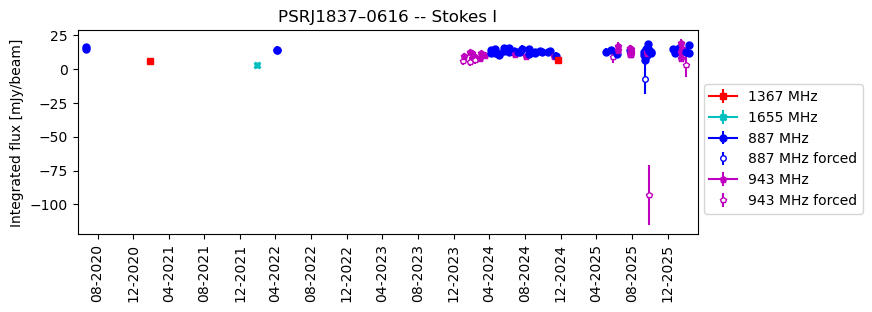

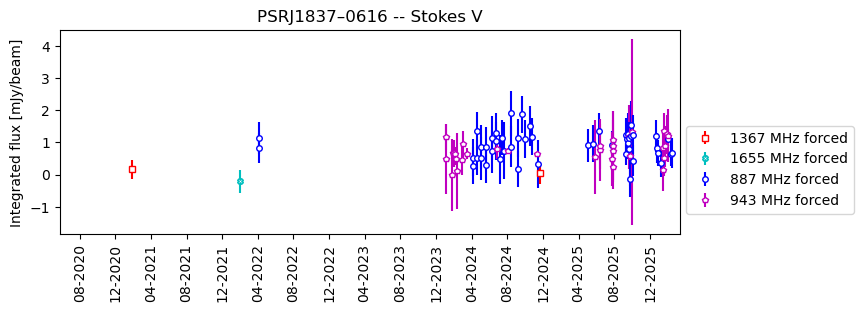

In [42]:
plot_light_curve(source_name, df, 'I', plots_folder)
plot_light_curve(source_name, df, 'V',plots_folder) 

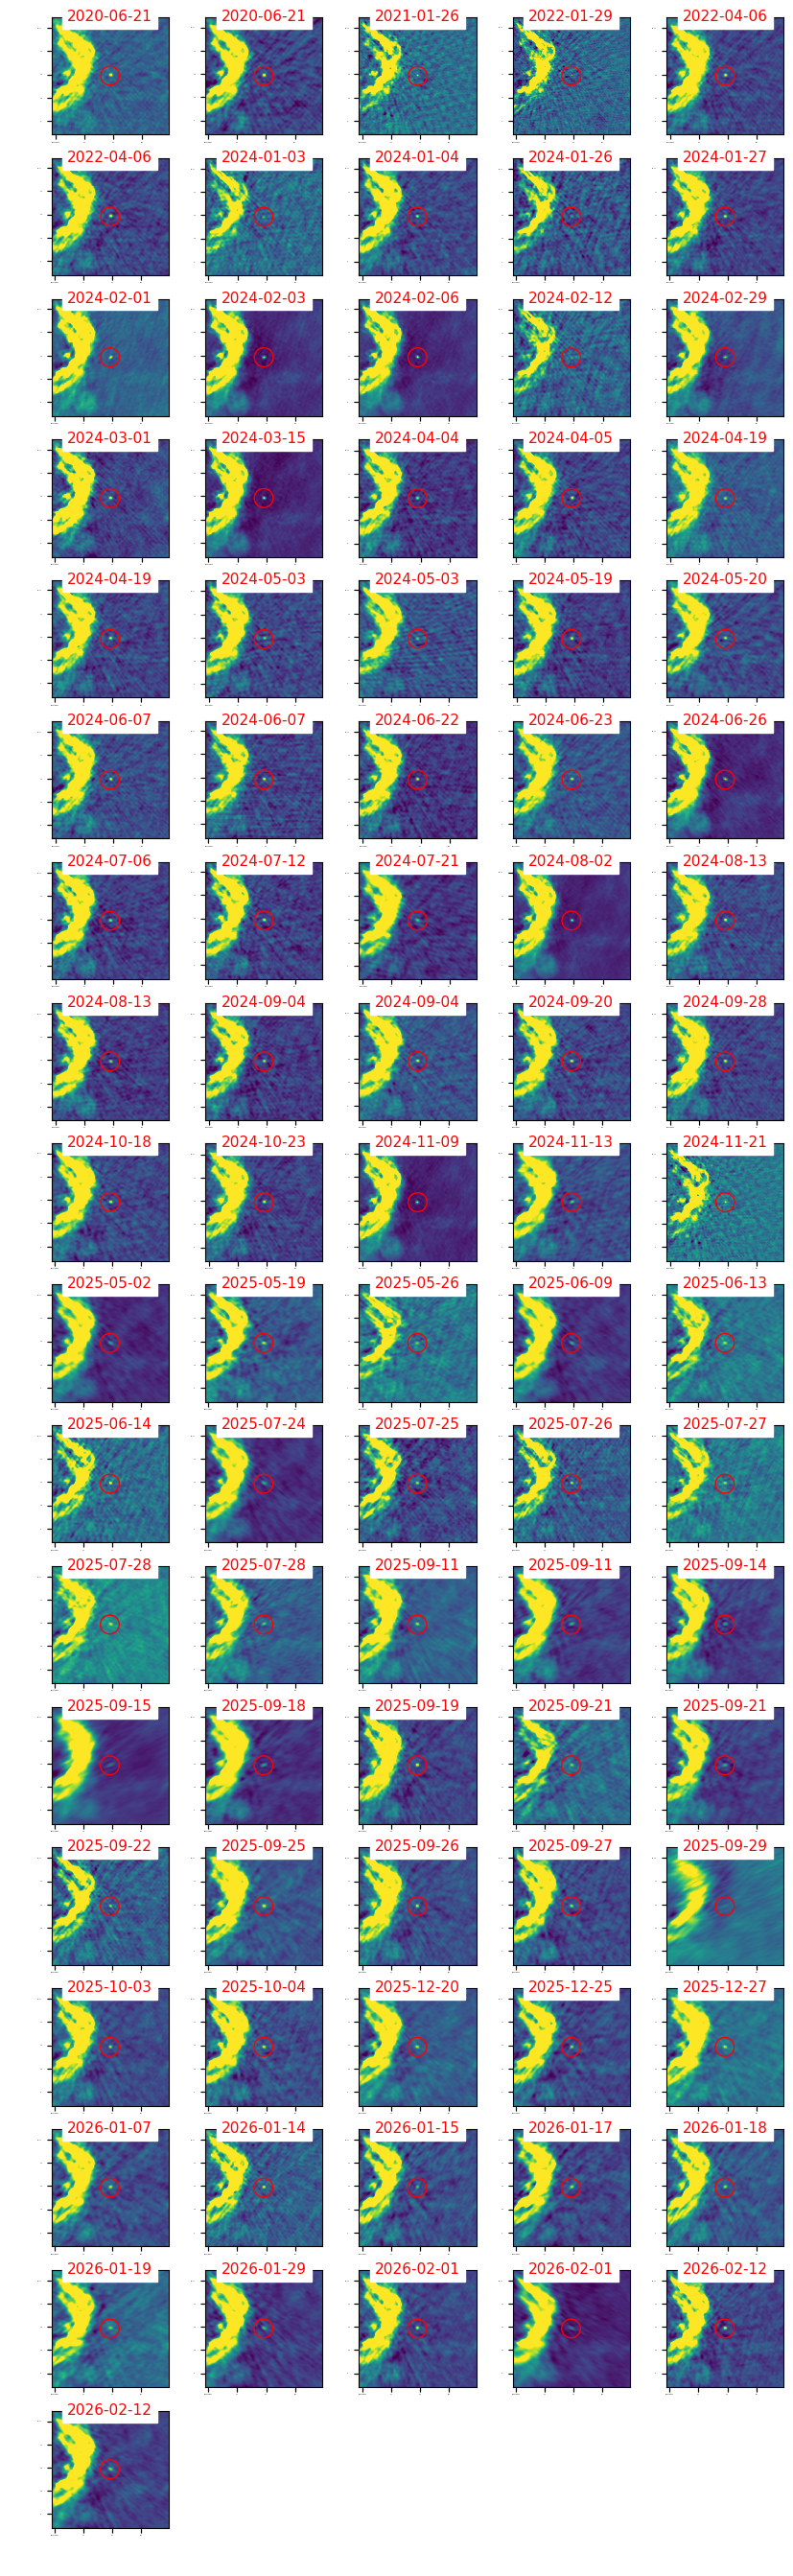

In [99]:
create_plot_grid(stokes='I', df=df, ra=ra, dec=dec, plots_folder = plots_folder)


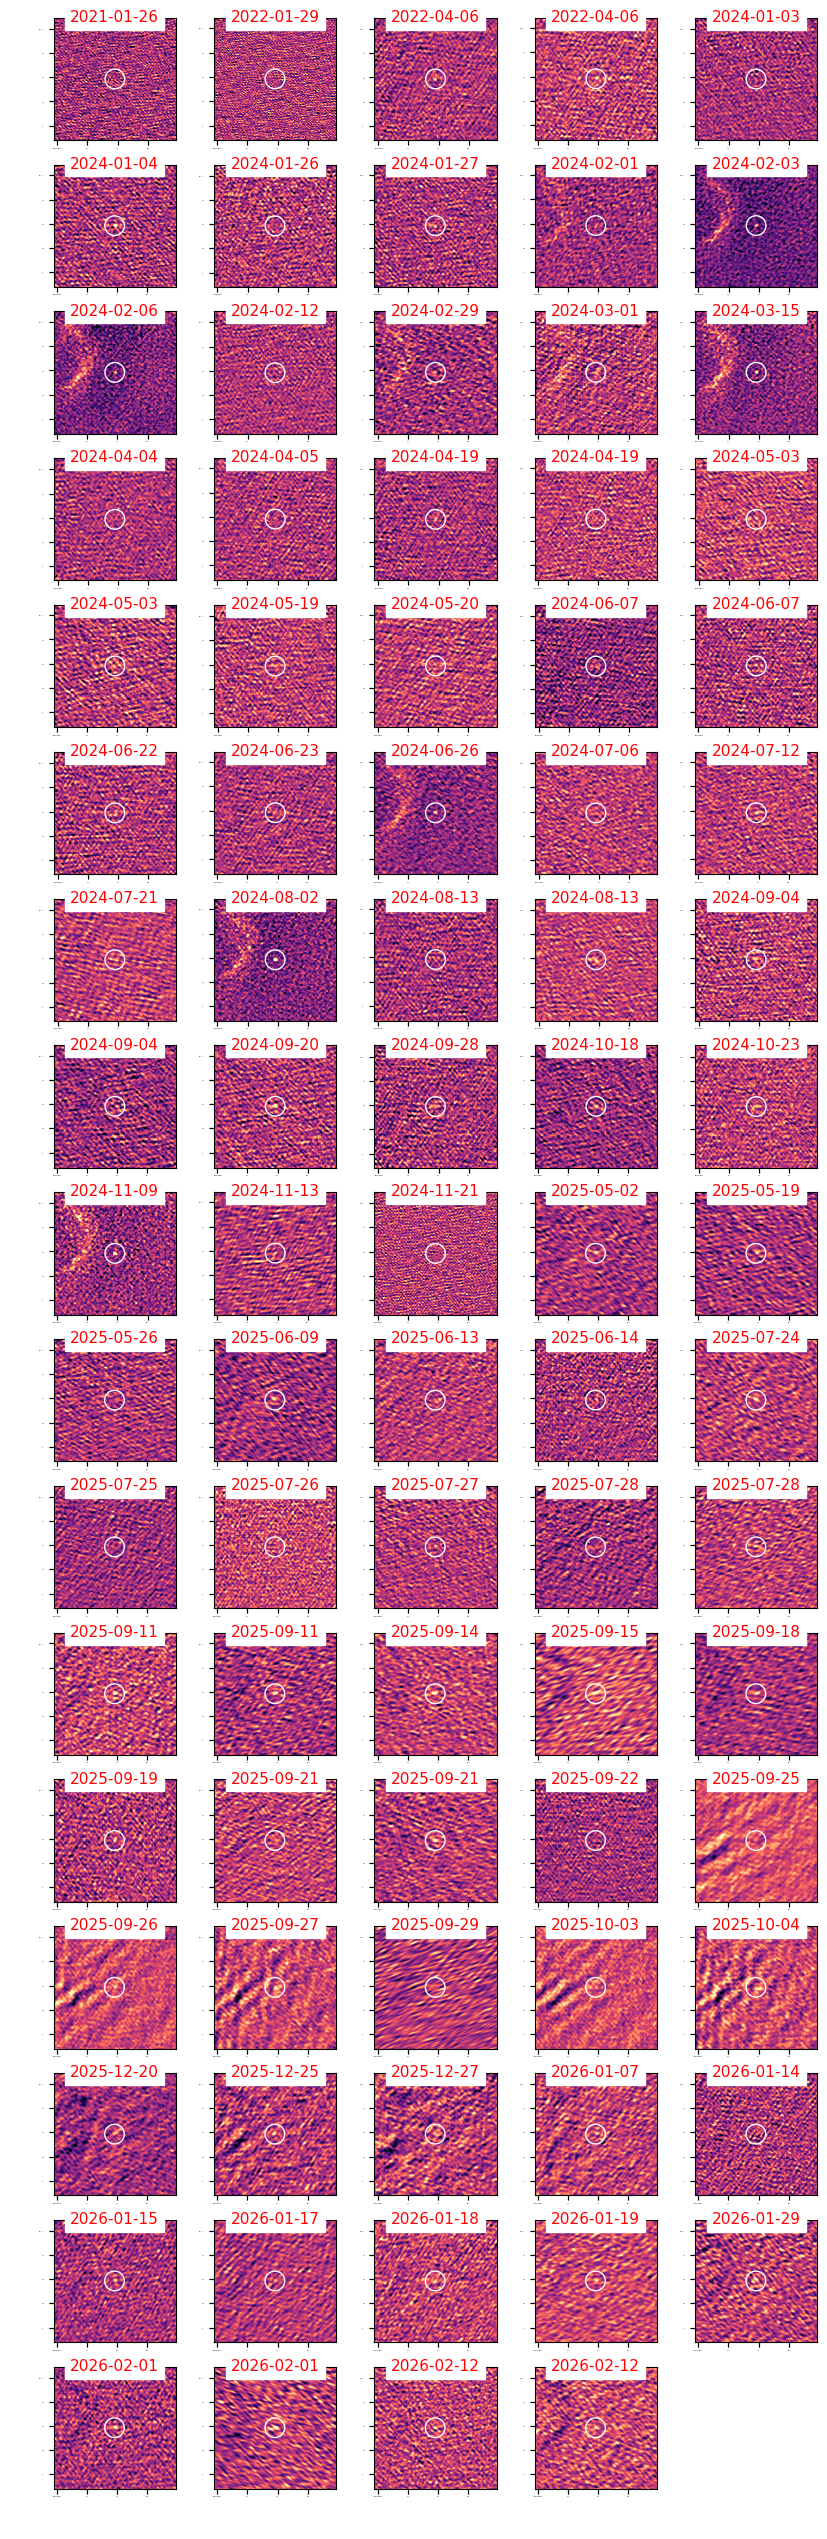

In [100]:
create_plot_grid(stokes='V', df=df, ra=ra, dec=dec, plots_folder = plots_folder)
